In [3]:
import astropy 
from astropy.io import fits
from astropy.wcs import WCS
from astropy.utils.data import get_pkg_data_filename
from photutils.datasets import load_star_image
from photutils.detection import DAOStarFinder
from astropy.stats import mad_std
from photutils.aperture import aperture_photometry, CircularAperture

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
from scipy.optimize import curve_fit 

In [ ]:
#Functions


def pixel_coord_plot(filename):
    """
    Plot a FITS image file in pixel coordinates. This function reads a FITS file containing image data and displays it using Matplotlib.

    Arguments:
    filename : str
        The path to the FITS file to be plotted

    Returns:
    None
        This function displays the plot directly, without any return

    """

    image_data = fits.getdata(filename)

    plt.figure(figsize=(5, 5))
    plt.imshow(image_data, cmap='gray', vmin = 0 , vmax = 4) #set the range of cmap to correct the image 
    plt.title('Globular Cluster NGC 104- Pixel Coordinates')
    plt.xlabel('X Pixels')
    plt.ylabel('Y Pixels')
    plt.colorbar()

def check_wcs(filename):
    """
    Check for the presence of World Coordinate System (WCS) information in a FITS file.

    Arguments:
    filename : str
        The path to the FITS file to be checked

    Returns:
    header : 
        The header of the FITS file, which contains data its structure.
    
    image_data : array
        The image data extracted from the FITS file
    """

    with fits.open(filename) as hdulist:
        image_data = hdulist[1].data  #access data from hdu 
        header = hdulist[1].header    #access header from hdu 

    #check if wcs information is present
    wcs_keywords = ['WCSAXES', 'CTYPE1', 'CTYPE2', 'CRVAL1', 'CRVAL2', 'CRPIX1', 'CRPIX2'] 
    wcs_present = any(keyword in header for keyword in wcs_keywords)

    if wcs_present:
        print("\nWCS information is present in the FITS header.")
    else:
        print("\nNo WCS information found in the FITS header.")

    return header, image_data


def sky_coord_concert(header, image_data):
    """
    Convert the image data to World Coordinate System (WCS) sky coordinates (Right Ascension (RA) and Declination (Dec)) and plot the image.

    Arguments:
    header :
        The header of the FITS file containing WCS information

    image_data : array
        The image data extracted from the FITS file

    Returns:
        This function directly displays the plot

    """
    
    wcs = WCS(header)

    #plot the image using wsc to show sky coordinates
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection=wcs)

    ax.imshow(image_data, cmap='gray', vmin=0, vmax=5)  # Adjust contrast as needed

    #set the axes names for the corresponding sky coordinates 
    ax.set_xlabel('Right Ascension (RA)')
    ax.set_ylabel('Declination (Dec)')
    ax = plt.subplot(projection=wcs)

    # Add a title
    ax.set_title('Globular Cluster NGC 104 - Sky Coordinates')

    # Show the plot
    plt.show()


def remove_nan(image_data):
    """
    This function takes an image array, masks any NaN or invalid values, 
    subtracts the median of the valid data and replaces any NaN values with zeros.

    Arguments:
    image_data : array
        The input image data

    Returns:
    new_image : array
        The processed image data with NaN values masked and replaced with zeros, and the background subtracted from the data.
    """
    masked_image = np.ma.masked_invalid(image_data) #using numpy's function to mask the NAN values 

    image_data1 = masked_image - np.ma.median(masked_image) #subtract the background from image_data 

    new_image = np.ma.filled(image_data1, 0)#replace them with zeros  

    return new_image 


def detect_stars(new_image):
    """
    Detect stars in an image using `DAOStarFinder`, perform aperture photometry on the detected sources. Then the functions plots the apertures 
    on rop of the data results.

    Arguments:
    new_image : array
        The processed image data to detect for stars.

    Returns:
    -------
    sources : table
        A table of detected sources 
    
    phot_table : table
        A table of aperture photometry results for the detected sources.

    """
    
    bkg_sigma = mad_std(new_image)  #estimated sigma noise level using the median absolute deviation
    daofind = DAOStarFinder(fwhm=4.0, threshold=3.0 * bkg_sigma)  #detection threshold at the 3-sigma noise level
    sources = daofind(new_image)  
    
    print(f"Stars detected: {len(sources)}") 

    #found the following commands from here: https://photutils.readthedocs.io/en/stable/getting_started.html
    positions = np.transpose((sources['xcentroid'], sources['ycentroid']))  

    apertures = CircularAperture(positions, r=4.0)  

    phot_table = aperture_photometry(new_image, apertures)  

    for col in phot_table.colnames:  
            phot_table[col].info.format = '%.8g'  # for consistent table output

    
    plt.imshow(new_image, cmap='gray', origin='lower')
    apertures.plot(color='blue', lw=1.5, alpha=0.5)
    plt.xlabel('X Axes')
    plt.ylabel('Y Axes')
    plt.title('Detected Stars')
    plt.show()

    return sources 



#define the one dimensional gaussian function 
def gaussian(x, Amp, mu, sigma, D):
    return Amp * np.exp(-(x - mu)**2 / (2 * sigma**2)) + D 


def histograms(sources):
    """
    Generate histograms of star positions along the x and y pixel axes using the sources table, fit Gaussian curves,
    and plot the results. Also. this function finds the optimal gaussian parameters

    Arguments:
    sources : table
        A table of detected sources

    Returns:
    poptx : array
        Optimal parameters for the Gaussian fit of the x-axis histogram

    popty : array
        Optimal parameters for the Gaussian fit of the y-axis histogram

    """
    x = sources['xcentroid']
    y = sources['ycentroid']

    #create the histograms arrays 
    x_hist, x_edges = np.histogram(x, bins=100)
    y_hist, y_edges = np.histogram(y, bins=100)


    #calculate the centers of the bins 
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2

    #initial guess of the parameters 
    p0 = [x_hist.max(), 2000, 1000, 250]

    #use the centers of the histogram's bins as a linspace 
    xg = np.linspace(x_centers[1], x_centers[-2], 100)
    yg = np.linspace(y_centers[1], y_centers[-2], 100)

    #Find the optimal gaussian parameters with curve fit 
    poptx, pcovx = curve_fit(gaussian, xg, x_hist, p0)
    popty, pcovy = curve_fit(gaussian, yg, y_hist, p0)

    print("The optimal gaussian values for the x-Histogram are:", poptx)
    print("The optimal gaussian values for the y-Histogram are:", popty)

    #plot the histogram along the x axes of the pixel coordinates 
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)

    plt.bar(x_centers, x_hist, width=(x_edges[1] - x_edges[0]), color='tan', alpha=0.7)
    plt.plot(xg, gaussian(xg, *poptx), color = 'slategray') #plot the gaussian with the optimal parameters 
    plt.xlabel('x position ')
    plt.ylabel('Number of stars')
    #plt.legend('Number of stars at x pixel axis', 'fitted gaussian curve')
    plt.title('x-Histogram')

    #plot the histogram along the y axes of the pixel coordinates 
    plt.subplot(1, 2, 2)
    plt.bar(y_centers, y_hist, width=(y_edges[1] - y_edges[0]), color='cadetblue', alpha=0.7)
    plt.plot(yg, gaussian(yg, *popty), color = 'orangered') #plot the gaussian with the optimal parameters 
    plt.xlabel('y position')
    plt.ylabel('Number of stars')
    #plt.legend('Number of stars at y pixel axis', 'fitted gaussian curve')
    plt.title('y-Histogram')

    plt.tight_layout()
    plt.show()
    
    return poptx, popty




def surface_density(r_hist):
    """
    Calculate the surface density of stars in a globular cluster based on the radial histogram. Specifically,
    This function calculates the surface density of stars as a function of the radial distance from the center of the cluster.
    The surface density is defined as the number of stars per unit area in annulus of radius, and also computing 
    the error bars.

    Arguments
    r_hist : tuple
        r_hist[0] : array
            the number of stars detected in each annulus
        r_hist[1] : array
            the radii defining the boundaries of the annuli

    Returns:
    surf_density : array
        The surface density of stars in each annulus, defined as the number of stars per unit area.

    errors : array
        The error estimates for the surface density in each annulus

    annulli_center : array
        The central radii of the annuli, calculated as the mean of the inner and outer radii of each annulus.
    """

    area = np.pi*(r_hist[1][1:]**2 - r_hist[1][:-1]**2)

    surf_density = r_hist[0] / area

    annulli_center = np.convolve(r_hist[1], np.array([0.5, 0.5]), mode= 'valid')

    errors = np.sqrt(r_hist[0]) / area

    return surf_density, annulli_center, errors 

def surface_density_plot(poptx, popty, sources):
    """
    This function calculates the radial distance of stars from the cluster center, 
    creates a histogram of these radii, computes the surface density and 
    plots the result with error bars.

    Arguments:
    poptx : array
        The optimal parameters of the Gaussian fit for the x-axis histogram

    popty : array
        The optimal parameters of the Gaussian fit for the y-axis histogram

    sources : table
        A table of detected sources

    Returns:
    surf_density : array
        The calculated surface density of the stars in each annulus.
    
    annuli_center : array
        The radial distances at the center of each annulus in arcseconds.
    
    errors : array
        The errors associated from the surface density.
    
    """
    #cluster center derived from gaussian 
    x_center = poptx[1]
    y_center = popty[1]

    #calculate pixel radii at which the star were detected 
    radius = np.sqrt((sources['xcentroid'] - x_center)**2 + (sources['ycentroid'] - y_center)**2) 
    radius_arc = radius * 0.04
    radius_arc = radius_arc[radius_arc < 2000*0.04] #limit to <2000 pixels

    #create histogram of radii 
    r_hist = np.histogram(radius_arc, bins=100)

    surf_density, annuli_center, errors = surface_density(r_hist)

    fig= plt.figure()
    plt.errorbar(annuli_center, surf_density, errors,  fmt='o', 
                color='darkkhaki', ecolor='lightgray', elinewidth=2)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('radius [arcsec]')
    plt.ylabel(r'Surface Density [arcsec$^{-2}]$')
    plt.title('Surface Density of Globular Cluster NGC 104')
    plt.show()

    return surf_density, annuli_center, errors 


 

def King_model(r, a, gamma, n0):
    """
    Calculate the stellar density profile of a King model.

   Arguments:
    r : array
        The radius from the center of the cluster at which to evaluate the stellar density
    
    a : float
        The core radius of the King model
    
    gamma : float
        The slope parameter of the King model (typically: 0 < gamma < 3)

    n0 : float
        The central stellar density

    Returns:
    n_stellar_dens : array
        The calculated stellar density at each radius

    """
    n_stellar_dens = n0 * (1 + (r/a)**2 )**(-gamma/2)
    return n_stellar_dens


def king_model_fit(annuli_center, surf_density, errors):
    """
    This function fits a King model to the observed surface density data of a globular cluster, 
    calculates the core radius r_c of the cluster, and plots
    the fit king model on top of the observed data.

    Arguments:
    surf_density : array
        The calculated surface density of the stars in each annulus.
    
    annuli_center : array
        The radial distances at the center of each annulus in arcseconds.
    
    errors : array
        The errors associated from the surface density.

    Returns:
    This function only plots the fit curve with the data, and prints the value of the core radius 
    """
    #initial guess of the king model parameters [a = 8, gamma = 1, n0 = 3]
    p0 = [20,1,5]
    poptk, pcov = curve_fit(King_model, annuli_center, surf_density, p0, sigma = errors)
    print(poptk)

    r_c = poptk[0]*np.sqrt((2**(2/poptk[1])-1))
    print('The core radius (r_c) of the cluster in arcsec is:' , r_c)

    plt.figure(figsize=(10, 5))
    plt.plot(annuli_center, King_model(annuli_center, *poptk), color = 'orangered')
    plt.errorbar(annuli_center, surf_density, errors,  fmt='o', 
                color='darkkhaki', ecolor='lightgray', elinewidth=2)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('radius [arcsec]')
    plt.ylabel(r'Surface Density [arcsec$^{-2}]$')
    plt.title('Surface Density of Globular Cluster NGC 104')
    plt.legend(['King model fit', 'surface density data'])
    plt.grid()
    plt.show()



Filename: ic2r02050_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1189   ()      
  1  SCI           1 ImageHDU        93   (4203, 4536)   float32   
  2  WHT           1 ImageHDU        47   (4203, 4536)   float32   
  3  CTX           1 ImageHDU        42   (4203, 4536)   int32   
  4  HDRTAB        1 BinTableHDU    559   24R x 275C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 11A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, 8A, 23A, D, D, D, D, K, K, 8A, 23A, 9A, 18A, 4A, K, D, D, D, K, K, K, K, 23A, D, D, D, D, K, K, 4A, 3A, 4A, L, D, D, D, 23A, 1A, K, D, D, D, 4A, 1A, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 4A, 3A, 3A, 4A, 8A, 7A, D, K, D, 6A, 9A, 8A, D, D, 4A, 18A, 3A, K, 5A, 3A, D, 10A, 8A, 8A, 23A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, L, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D, D, D, 1A, K, K, K, K, D, 3A, K, D, 5A, 7A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D

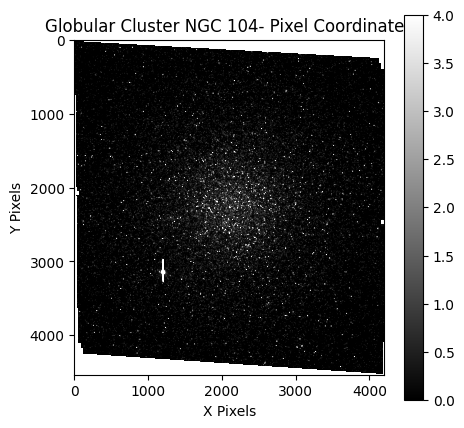

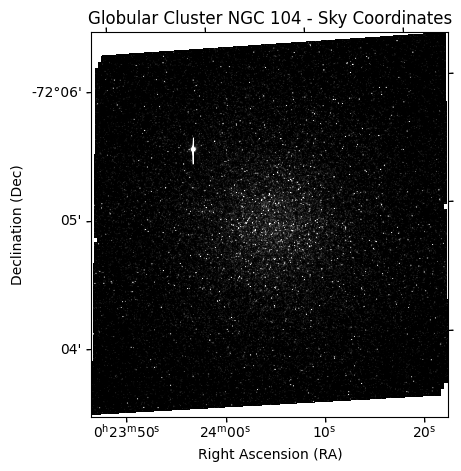

In [ ]:

filename = 'ic2r02050_drz.fits'

#open file 
hdu_file = fits.open(filename)
hdu_file.info()

pixel_coord_plot(filename)
header, image_data = check_wcs(filename)
sky_coord_concert(header, image_data)


Stars detected: 66649


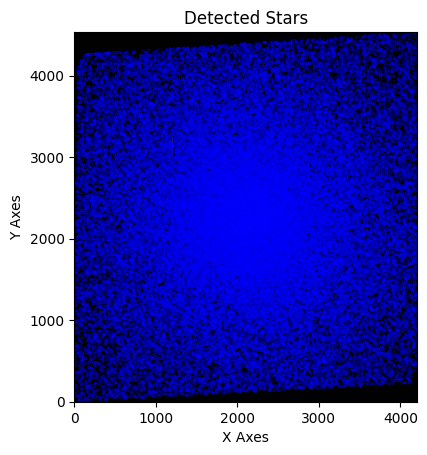

In [ ]:
new_image = remove_nan(image_data)
sources = detect_stars(new_image)

The optimal gaussian values for the x-Histogram are: [ 747.37645937 2131.84785725  758.01427367  323.73959517]
The optimal gaussian values for the y-Histogram are: [ 946.72897364 2234.68802221  960.01399721  163.93158726]


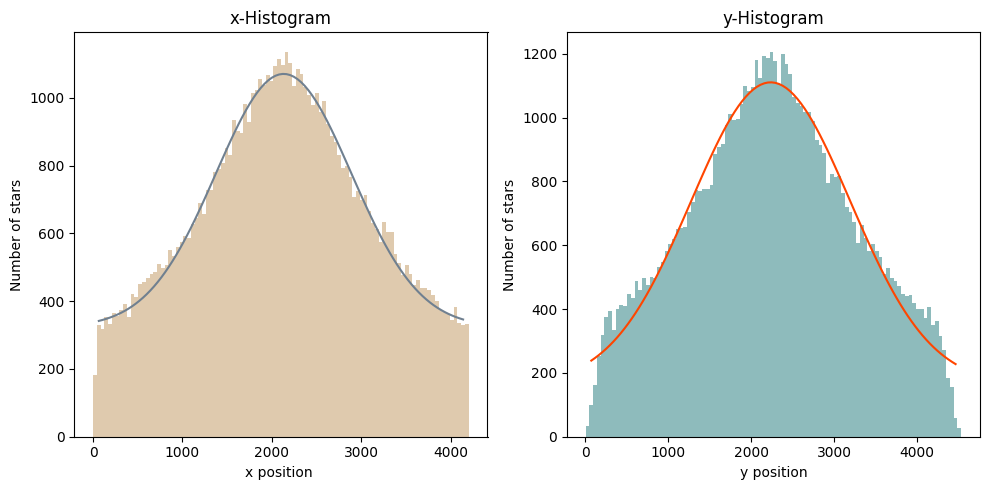

In [ ]:
poptx, popty = histograms(sources)

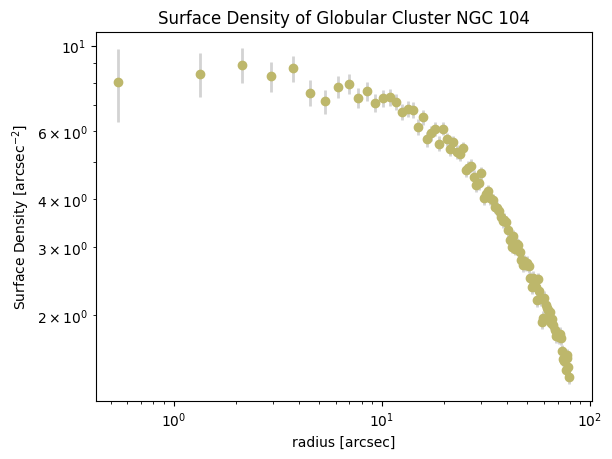

In [ ]:

surf_density, annuli_center, errors = surface_density_plot(poptx, popty, sources)

[27.12811627  1.49283717  7.94360587]
The core radius (r_c) of the cluster in arcsec is: 33.56703954711


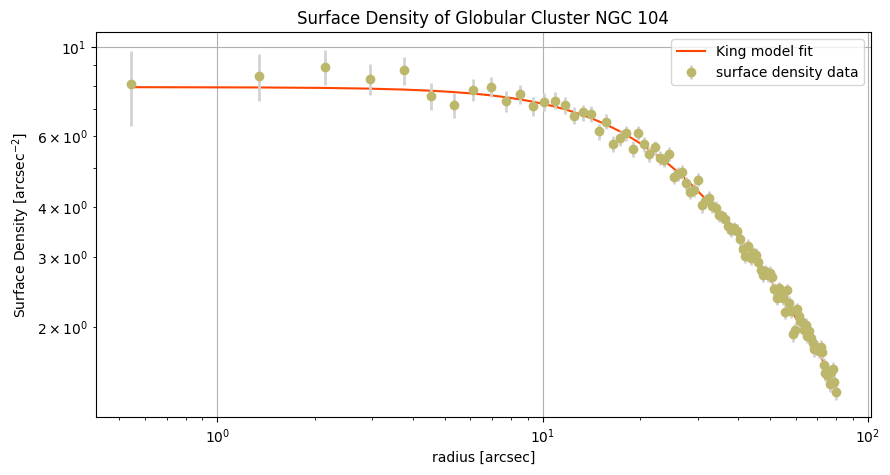

In [ ]:
king_model_fit(annuli_center, surf_density, errors)